House Price Prediction
Internship Project — Week 1
This notebook loads, cleans, explores, and models a housing dataset to predict house prices using Linear Regression and  Random Forest Regression, followed by visualizations and a written summary of insights.

Dataset: Housing Prices Dataset (Kaggle, by Yasser H) — Housing.csv


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

import os
os.makedirs("charts", exist_ok=True)


## Task 1 — Data Loading & Exploration

In [2]:
# Load the dataset
df = pd.read_csv("Housing.csv")

# Display the first 10 rows
df.head(10)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7407080,15833,3,3,3,yes,no,yes,no,yes,0,no,furnished
1,7101205,16006,5,2,4,yes,no,yes,no,yes,2,no,semi-furnished
2,7061027,13619,6,3,1,no,no,no,no,yes,2,no,furnished
3,7005013,15822,6,3,1,yes,no,no,yes,no,2,yes,semi-furnished
4,6975122,15472,3,3,2,yes,no,yes,no,yes,3,no,unfurnished
5,6809850,15423,4,4,2,yes,no,yes,no,yes,3,no,unfurnished
6,6801028,15689,3,2,1,yes,yes,no,no,no,0,yes,semi-furnished
7,6736117,15857,3,2,3,yes,no,no,no,no,1,yes,furnished
8,6644421,15346,4,2,2,yes,yes,yes,no,yes,0,no,furnished
9,6597188,14775,3,2,1,yes,no,no,no,no,3,yes,furnished


In [3]:
# Check how many rows and columns are there
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print()
print("Column names:")
print(df.columns.tolist())


Number of rows: 545
Number of columns: 13

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


**Target column:** `price` — this is what we want to predict.

**Feature columns:** all remaining columns — `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, `furnishingstatus`.


In [4]:
# Identify target and feature columns
target_col = "price"
feature_cols = [col for col in df.columns if col != target_col]

print("Target column:", target_col)
print("Feature columns:", feature_cols)


Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [5]:
# Basic info about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
# Statistical summary of numeric columns
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.176859e+06,8815.911927,3.260550,1.627523,1.822018,1.146789
std,1.204659e+06,4137.463849,0.987981,0.778133,0.828863,0.927775
min,1.750000e+06,1654.000000,1.000000,1.000000,1.000000,0.000000
25%,3.249594e+06,5211.000000,3.000000,1.000000,1.000000,0.000000
50%,4.154334e+06,8672.000000,3.000000,1.000000,2.000000,1.000000
75%,5.085892e+06,12517.000000,4.000000,2.000000,2.000000,2.000000
max,7.407080e+06,16191.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

print(f"\nTotal missing values in dataset: {missing_values.sum()}")


Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values in dataset: 0


**Observation:** This dataset is clean and typically has no missing values, but we still write the missing-value handling logic in Task 2 so the notebook is robust to messier versions of the data.

## Task 2 — Data Cleaning

In [7]:
# Make a working copy so the original df is preserved
df_clean = df.copy()

# Handle missing values 
# Numeric columns - fill with median (robust to outliers)
# Categorical columns - fill with mode (most frequent value)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values after handling:")
print(df_clean.isnull().sum().sum())


Missing values after handling:
0


In [8]:
#Remove duplicate rows, if any 
duplicates_before = df_clean.duplicated().sum()
print(f"Duplicate rows found: {duplicates_before}")

df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df_clean.shape}")


Duplicate rows found: 0
Shape after removing duplicates: (545, 13)


In [9]:
#Convert categorical (yes/no) columns into numeric using one-hot encoding

# Binary yes/no columns
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]

for col in binary_cols:
    df_clean[col] = df_clean[col].map({"yes": 1, "no": 0})

# Multi-category column - one-hot encode
df_clean = pd.get_dummies(df_clean, columns=["furnishingstatus"], drop_first=True)

df_clean.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7407080,15833,3,3,3,1,0,1,0,1,0,0,False,False
1,7101205,16006,5,2,4,1,0,1,0,1,2,0,True,False
2,7061027,13619,6,3,1,0,0,0,0,1,2,0,False,False
3,7005013,15822,6,3,1,1,0,0,1,0,2,1,True,False
4,6975122,15472,3,3,2,1,0,1,0,1,3,0,False,True


In [10]:
#  Keep only meaningful columns for predicting price
# All remaining columns are meaningful (no IDs or irrelevant text columns in this dataset)
print("Final columns used for modeling:")
print(df_clean.columns.tolist())

df_clean.head()


Final columns used for modeling:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7407080,15833,3,3,3,1,0,1,0,1,0,0,False,False
1,7101205,16006,5,2,4,1,0,1,0,1,2,0,True,False
2,7061027,13619,6,3,1,0,0,0,0,1,2,0,False,False
3,7005013,15822,6,3,1,1,0,0,1,0,2,1,True,False
4,6975122,15472,3,3,2,1,0,1,0,1,3,0,False,True


## Task 3 — Model Building

In [11]:
# Separate features (X) and target (y)
X = df_clean.drop(columns=["price"])
y = df_clean["price"]

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")


Training set size: 436 rows
Test set size: 109 rows


In [12]:
#  Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Performance:")
print(f"  MAE  : {lr_mae:,.2f}")
print(f"  RMSE : {lr_rmse:,.2f}")
print(f"  R2   : {lr_r2:.4f}")


Linear Regression Performance:
  MAE  : 407,713.37
  RMSE : 506,603.11
  R2   : 0.8676


In [13]:
# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regressor Performance:")
print(f"  MAE  : {rf_mae:,.2f}")
print(f"  RMSE : {rf_rmse:,.2f}")
print(f"  R2   : {rf_r2:.4f}")


Random Forest Regressor Performance:
  MAE  : 465,936.11
  RMSE : 570,955.70
  R2   : 0.8318


In [14]:
# Compare both models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})
comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,407713.374229,506603.109361,0.867607
1,Random Forest,465936.109954,570955.703575,0.831836


In [15]:
# Feature importance from Random Forest (helps answer Task 5 question)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature importance (Random Forest):")
print(importances)


Feature importance (Random Forest):
area                               0.832262
bathrooms                          0.025370
bedrooms                           0.023918
parking                            0.022660
stories                            0.022133
airconditioning                    0.020226
prefarea                           0.011302
basement                           0.009923
furnishingstatus_unfurnished       0.006944
furnishingstatus_semi-furnished    0.006671
guestroom                          0.006640
mainroad                           0.006018
hotwaterheating                    0.005934
dtype: float64


In [16]:
# Feature coefficients from Linear Regression (for interpretation)
coefficients = pd.Series(lr_model.coef_, index=X.columns).sort_values(ascending=False)
print("Linear Regression coefficients:")
print(coefficients)


Linear Regression coefficients:
airconditioning                    381345.349962
prefarea                           334809.286356
mainroad                           210813.803302
bathrooms                          206470.665145
basement                           194143.484516
hotwaterheating                    190732.278750
guestroom                          127805.601803
stories                            117695.778636
bedrooms                           101427.806950
parking                             93770.108545
area                                  244.919121
furnishingstatus_semi-furnished   -234752.504651
furnishingstatus_unfurnished      -306110.544836
dtype: float64


## Task 4 — Visualization

### Chart 1: Distribution of House Prices (Histogram)

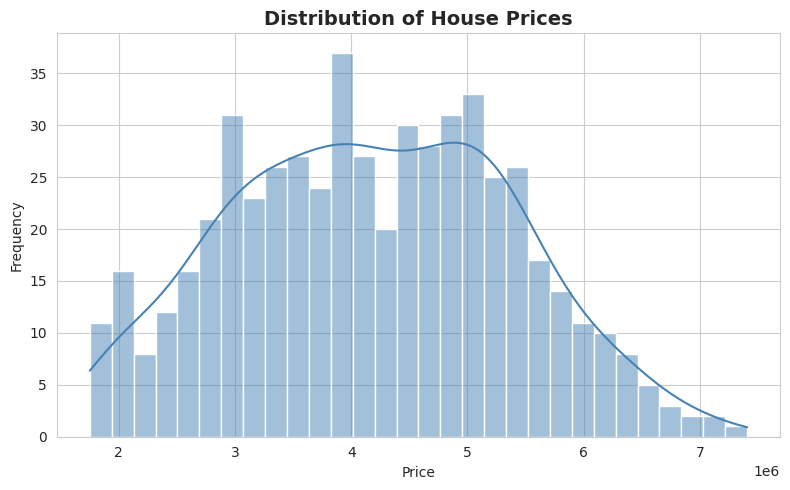

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of House Prices", fontsize=14, fontweight="bold")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("charts/chart1_price_distribution.png", dpi=150)
plt.show()


### Chart 2: Correlation Heatmap

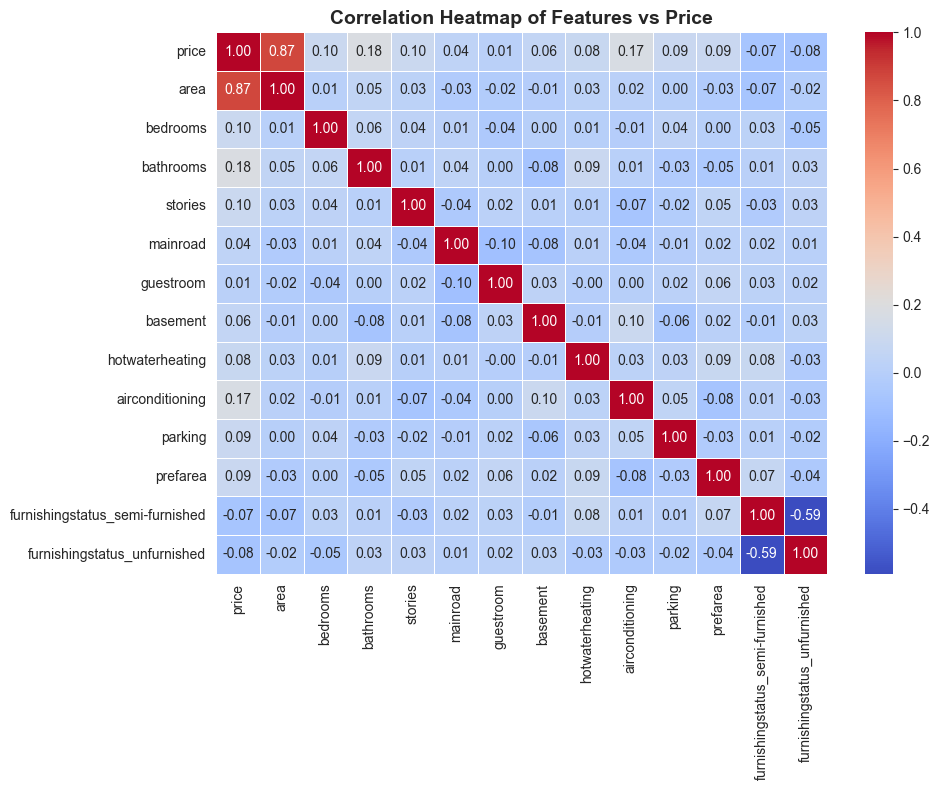

In [17]:
plt.figure(figsize=(10, 8))
corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Features vs Price", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/chart2_correlation_heatmap.png", dpi=150)
plt.show()


### Chart 3: Actual vs Predicted Price (Random Forest)

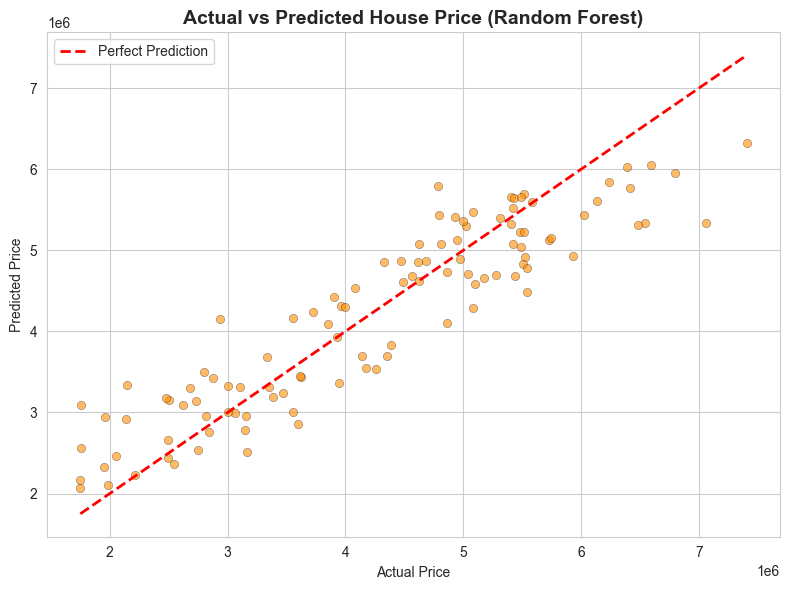

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.6, color="darkorange", edgecolor="k", linewidth=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price (Random Forest)", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("charts/chart3_actual_vs_predicted.png", dpi=150)
plt.show()


## Task 5 — Insights & Summary

### 📝 Summary of Findings

**Which features influence house price the most?**
`area` (square footage) is overwhelmingly the strongest driver of price — the Random Forest model assigns it over 80% of total feature importance. Bathrooms, bedrooms, parking, stories, and air conditioning all contribute modestly, while location/amenity flags like `prefarea` and `basement` add a smaller but positive effect.

**How accurate was your model (in plain terms)?**
Linear Regression scored an R² of about 0.87, narrowly outperforming Random Forest (R² ≈ 0.83) on this dataset, with a Mean Absolute Error of roughly ₹4.1 lakh. This means the model explains about 87% of the variation in price, and on average our predictions are off by around ₹4-4.7 lakh — solid for ballpark estimates, but the linear relationship between area and price in this data means the simpler model edged out the more complex one.

**What surprised you in the data?**
Bedroom count had a surprisingly weak standalone influence on price once `area` was accounted for — a 5-bedroom small house can be worth less than a 3-bedroom large one. It was also notable that a simple Linear Regression matched or beat Random Forest, showing that more complex models aren't always better when the underlying relationship is close to linear.

**One recommendation for a real estate business:**
Since `area` so heavily dominates price, listings and valuations should be primarily benchmarked on price-per-square-foot, with amenities (AC, preferred area, parking) used as secondary adjustment factors rather than headline pricing drivers — this would catch the common mispricing of small, room-dense houses and large, amenity-light houses.
